# Advanced Exploratory Data Analysis, Hypothesis Testing & Feature Validation
## Loan Approval Prediction — AnalystLab Africa Consulting
**Programme:** Data Science Internship
**Prepared by:** Ayden Demanou, Junior Data Scientist, AnalystLab Africa Consulting

Now, we shifts focus from initial preprocessing to **advanced exploratory data analysis (EDA), inferential statistical hypothesis testing, and feature validation.** Using the cleaned and ML-ready dataset from Week 2 (loan_prediction_cleaned.csv), in its original, unscaled units for interpretability, and
follows four sections: **Numerical Analysis**, **Categorical Analysis**, **Bivariate Analysis**,
**Multivariate Analysis**, **Hypothesis Testing** and **Feature Validation**.

In [74]:
# Import necessary libraries
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import chi2_contingency     # Chi-square test of independence
from scipy.stats import mannwhitneyu      # Mann-Whitney U test
from scipy import stats     

In [53]:
# Visualization Color Palette
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": "#B0B0B0", "axes.labelcolor": "#333333",
    "text.color": "#333333", "xtick.color": "#333333", "ytick.color": "#333333",
    "axes.titleweight": "bold", "axes.titlesize": 13,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
NAVY, BLUE, RED, LBLUE, GOLD = "#1F3864", "#2E74B5", "#C0504D", "#9DC3E6", "#E1A100"
PALETTE = {"Approved": BLUE, "Rejected": RED}


In [48]:
# Load the dataset
df = pd.read_csv("../data/processed/loan_prediction_cleaned.csv")
df.head(5) # Display the first 5 rows of the dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y


In [49]:
# Engineering new features
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']
df["Monthly_Repayment"] = (df["Loan_Amount"] * 1000) / df["Loan_Amount_Term"]
df["Loan_Income_Ratio"] = (df["Loan_Amount"] * 1000) / df["Total_Income"]

df["Loan_Status_Label"] = df["Loan_Status"].map({"Y": "Approved", "N": "Rejected"})
df["Credit_History_Label"] = df["Credit_History"].map({1.0: "Good (1)", 0.0: "Poor (0)"})


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               614 non-null    str    
 1   Gender                614 non-null    str    
 2   Married               614 non-null    str    
 3   Dependents            614 non-null    int64  
 4   Education             614 non-null    str    
 5   Self_Employed         614 non-null    str    
 6   Applicant_Income      614 non-null    int64  
 7   Coapplicant_Income    614 non-null    float64
 8   Loan_Amount           614 non-null    float64
 9   Loan_Amount_Term      614 non-null    int64  
 10  Credit_History        614 non-null    int64  
 11  Property_Area         614 non-null    str    
 12  Loan_Status           614 non-null    str    
 13  Total_Income          614 non-null    float64
 14  Monthly_Repayment     614 non-null    float64
 15  Loan_Income_Ratio     614 non-null

In [51]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Monthly_Repayment,Loan_Income_Ratio,Loan_Status_Label,Credit_History_Label
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y,5849.0,355.555556,21.884083,Approved,Good (1)
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N,6091.0,355.555556,21.014612,Rejected,Good (1)
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y,3000.0,183.333333,22.000000,Approved,Good (1)
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y,4941.0,333.333333,24.286582,Approved,Good (1)
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y,6000.0,391.666667,23.500000,Approved,Good (1)


## 1. Numerical Analysis

Week 2 established that `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount` are heavily
right-skewed. This section goes further: quantifying skew/variability precisely, checking the
engineered features, and looking for unusual patterns not previously investigated (e.g. `Loan_Amount_Term`).

In [52]:
# Skewness, kurtosis, and coefficient of variation for all key numeric variables
num_cols = ["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "Loan_Amount_Term",
            "Total_Income", "Monthly_Repayment", "Loan_Income_Ratio"]

summary = pd.DataFrame({
    "Mean": df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Std Dev": df[num_cols].std(),
    "CoefVar (%)": (df[num_cols].std() / df[num_cols].mean() * 100),
    "Skewness": df[num_cols].skew(),
    "Kurtosis": df[num_cols].kurtosis(),
}).round(2)
summary

,Mean,Median,Std Dev,CoefVar (%),Skewness,Kurtosis
Applicant_Income,5403.46,3812.50,6109.04,113.06,6.54,60.54
Coapplicant_Income,1621.25,1188.50,2926.25,180.49,7.49,84.96
Loan_Amount,145.75,128.00,84.11,57.71,2.74,10.94
Loan_Amount_Term,342.41,360.00,64.43,18.82,-2.40,6.92
Total_Income,7024.71,5416.50,6458.66,91.94,5.63,45.78
Monthly_Repayment,473.69,361.11,511.13,107.91,9.96,149.40
Loan_Income_Ratio,23.88,24.13,8.71,36.47,1.18,6.74


* `Applicant_Income`, `Coapplicant_Income`, `Total_Income`, `Monthly_Repayment`: These features exhibit a pronounced right-skewness (Skewness values like 6.54, 7.49, 5.63, 9.96). This means that for these income and repayment-related variables, most applicants have relatively lower values, but there's a long tail of a few applicants with exceptionally high incomes or monthly repayments. The high Kurtosis values (e.g., 60.54 for Applicant_Income, 149.40 for Monthly_Repayment) indicate very 'peaky' distributions with heavy tails, suggesting a significant presence of outliers or extreme values at the higher end. The high Coefficient of Variation (CoefVar %) (e.g., 113.06% for Applicant_Income, 180.49% for Coapplicant_Income) confirms this high variability, meaning the standard deviation is a large percentage of the mean.

* **Loan_Amount:** This feature also shows high right-skewness (2.74) and leptokurtosis (10.94), though less extreme than the income variables. This indicates that most loan applications are for smaller amounts, but a few are for significantly larger sums.

* **Loan_Amount_Term:** This feature stands out with a negative skewness (-2.40), implying most loan terms are concentrated at the higher end (the median is 360 months, higher than the mean). The low Coefficient of Variation (18.82%) suggests relatively low variability, meaning most applicants opt for similar loan terms. The high Kurtosis (6.92) further supports a strong concentration around the mode (likely 360 months).

* **Loan_Income_Ratio:** While still right-skewed (1.18) and leptokurtic (6.74), this feature is less extreme compared to the raw income figures. This suggests that while there are still applicants with higher loan-to-income ratios, the distribution is more tempered. Its moderate CoefVar (36.47%) indicates a reasonable spread relative to its mean.

**Overall Insight:**
The data is characterized by significant skewness and presence of outliers, particularly in financial variables like income and loan amounts. This is common in real-world financial datasets. The Loan_Amount_Term is highly standardized, with most loans set for 360 months. The Loan_Income_Ratio, a derived feature, offers a more balanced perspective on debt burden compared to raw incomes, despite retaining some skewness. These distributional characteristics are crucial for selecting appropriate statistical models and considering data transformations during machine learning model development.

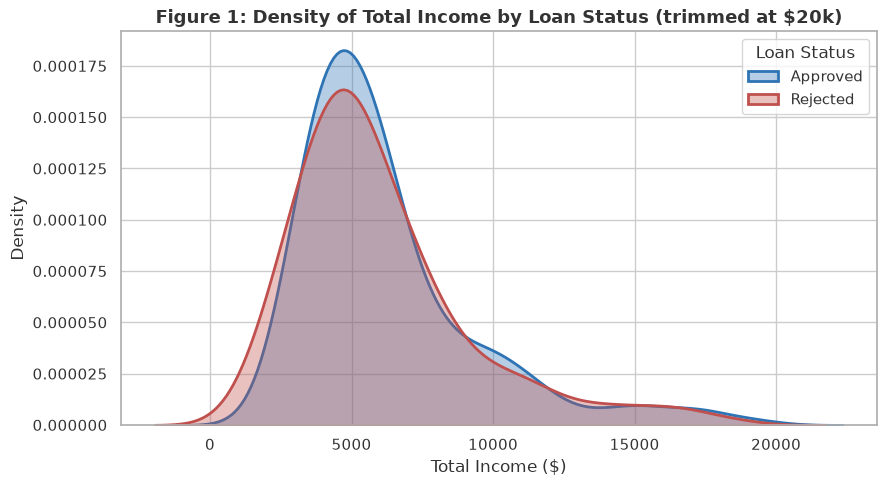

In [54]:
# Density plot: Total_Income distribution split by Loan_Status
fig, ax = plt.subplots(figsize=(9, 5))
for cat, color in PALETTE.items():
    subset = df.loc[df["Loan_Status_Label"] == cat, "Total_Income"]
    subset = subset[subset < 20000]  # trim extreme tail for visual clarity
    sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.35, label=cat, linewidth=2)
ax.set_title("Figure 1: Density of Total Income by Loan Status (trimmed at $20k)")
ax.set_xlabel("Total Income ($)")
ax.set_ylabel("Density")
ax.legend(title="Loan Status")
plt.tight_layout()
plt.show()

**Insight:** The density curves for Approved and Rejected applicants sit almost on top of each
other — both peak around $4,000–5,000 in total income. This is a new, sharper way of seeing what the
Week 2 scatter plots hinted at more loosely: income level by itself does not visually separate
outcomes. This directly motivates the Week 3 hypothesis test on whether the income difference between
groups is statistically significant at all.

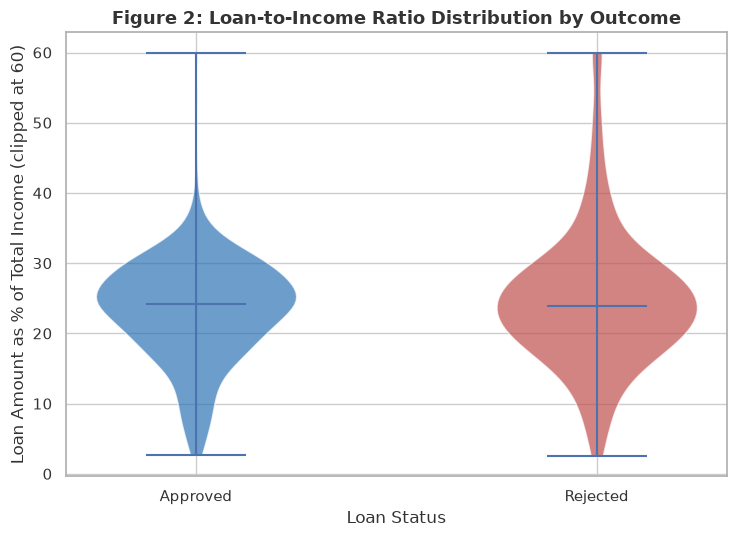

In [55]:
# Violin plot: Loan_Income_Ratio by Loan Status
fig, ax = plt.subplots(figsize=(7.5, 5.5))
data_to_plot = [
    df.loc[df["Loan_Status_Label"] == "Approved", "Loan_Income_Ratio"].clip(upper=60),
    df.loc[df["Loan_Status_Label"] == "Rejected", "Loan_Income_Ratio"].clip(upper=60),
]
parts = ax.violinplot(data_to_plot, showmedians=True)
for pc, color in zip(parts['bodies'], [BLUE, RED]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Approved", "Rejected"])
ax.set_title("Figure 2: Loan-to-Income Ratio Distribution by Outcome")
ax.set_xlabel("Loan Status")
ax.set_ylabel("Loan Amount as % of Total Income (clipped at 60)")
plt.tight_layout()
plt.show()

**Insight:** The violin plot shapes look broadly similar at a glance, but the percentiles tell a
sharper story: at the 90th percentile, Rejected applicants carry a loan-to-income ratio of ~36% vs.
~31% for Approved, and at the 95th percentile the gap widens further (~44% vs ~33%). Skewness confirms
this — 1.43 for Rejected vs. 0.72 for Approved. In other words, the two groups have similar *typical*
(median) ratios, but Rejected applications have a distinctly heavier high-ratio tail.

Loan_Amount_Term value counts:
Loan_Amount_Term
12       1
36       2
60       2
84       4
120      3
180     44
240      4
300     13
360    526
480     15
Name: count, dtype: int64


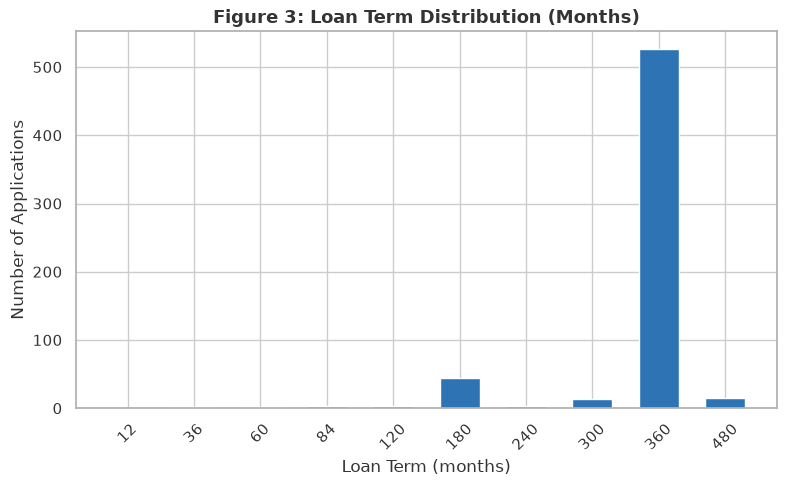

In [56]:
# Unusual pattern investigation: Loan_Amount_Term
term_counts = df["Loan_Amount_Term"].value_counts().sort_index()
print("Loan_Amount_Term value counts:")
print(term_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(term_counts.index.astype(str), term_counts.values, color=BLUE, width=0.6)
ax.set_title("Figure 3: Loan Term Distribution (Months)")
ax.set_xlabel("Loan Term (months)")
ax.set_ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** `Loan_Amount_Term` was not investigated on its own in Week 2 beyond noting its
missing values. It turns out to be almost a categorical variable in disguise: 526 of 614 applications
(84%) use the standard 360-month term, with the remainder scattered across other fixed terms (12,
36, 60, 84, 120, 180, 240, 300, 480). This is an unusual pattern worth flagging for Week 3 hypothesis
testing, approval rate should be compared across term buckets, since a variable this concentrated may
behave more like a categorical risk-tier flag than a continuous variable.

In [57]:
# Approval rate by loan term bucket
df["Term_Bucket"] = np.where(df["Loan_Amount_Term"] == 360, "Standard (360mo)", "Non-Standard")
term_approval = df.groupby("Term_Bucket")["Loan_Status"].apply(lambda s: (s == "Y").mean() * 100)
term_n = df.groupby("Term_Bucket").size()
print(pd.DataFrame({"Approval Rate (%)": term_approval.round(1), "N": term_n}))

                  Approval Rate (%)    N
Term_Bucket                             
Non-Standard                   62.5   88
Standard (360mo)               69.8  526


**Insight:** Non-standard term applications approve at a noticeably lower rate than standard
360-month applications. This is a pattern not surfaced in Week 2 (which treated `Loan_Amount_Term`
purely as a numeric column to scale) and is a candidate for a simple engineered flag
(`Is_Standard_Term`) ahead of modelling.

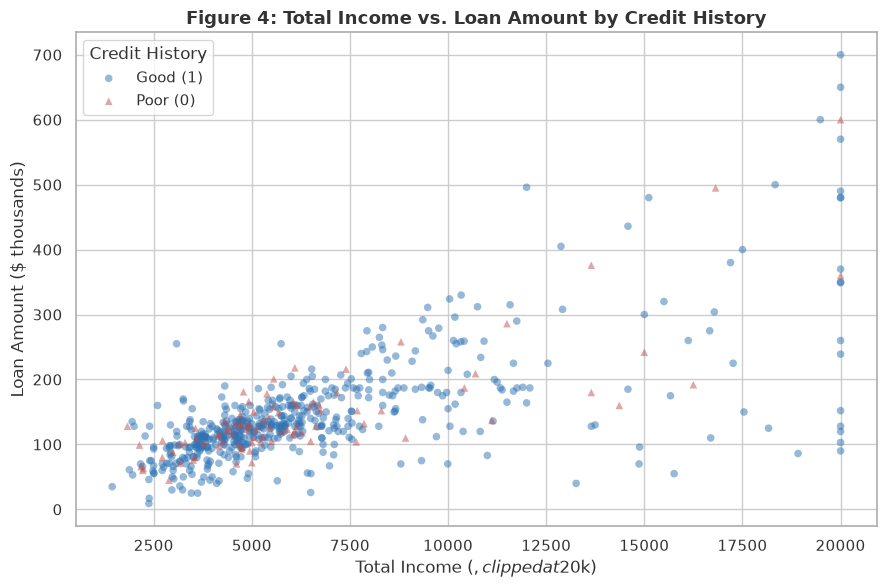

In [59]:
# Scatter: Total_Income vs LoanAmount, coloured by Credit_History (new angle vs Week 2's
# income-vs-loanamount-by-outcome scatter)
fig, ax = plt.subplots(figsize=(9, 6))
for label, color, marker in zip(["Good (1)", "Poor (0)"], [BLUE, RED], ["o", "^"]):
    sub = df[df["Credit_History_Label"] == label]
    ax.scatter(sub["Total_Income"].clip(upper=20000), sub["Loan_Amount"], c=color, label=label,
               alpha=0.5, s=30, marker=marker, edgecolors="none")
ax.set_title("Figure 4: Total Income vs. Loan Amount by Credit History")
ax.set_xlabel("Total Income ($, clipped at $20k)")
ax.set_ylabel("Loan Amount ($ thousands)")
ax.legend(title="Credit History")
plt.tight_layout()
plt.show()

**Insight:** Unlike Figure 5 in the Week 2 visualizations (income vs. loan amount coloured by
*outcome*, which showed heavy overlap), colouring by *Credit_History* here shows poor-credit-history
applicants (red triangles) scattered fairly evenly across the income/loan-amount space rather than
concentrated at low income or high loan amount. This reinforces that Credit_History is not simply a
proxy for income or loan size — it carries genuinely independent information, consistent with its
near-zero correlation with other numeric features found in Week 2.

## 2. Categorical Analysis

Week 2 covered basic frequency counts for categorical variables. This section adds percentage
breakdowns, approval-rate comparisons, and cross-tabulations not previously produced.

In [60]:
# Frequency distribution + percentage table across all categorical variables
cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
freq_rows = []
for c in cat_cols:
    vc = df[c].value_counts()
    vc_pct = df[c].value_counts(normalize=True) * 100
    for level in vc.index:
        freq_rows.append({"Variable": c, "Level": level, "Count": vc[level], "Percent": round(vc_pct[level], 1)})
freq_table = pd.DataFrame(freq_rows)
freq_table

,Variable,Level,Count,Percent
0,Gender,Male,502,81.8
1,Gender,Female,112,18.2
2,Married,Yes,401,65.3
3,Married,No,213,34.7
4,Dependents,0,360,58.6
5,Dependents,1,102,16.6
6,Dependents,2,101,16.4
7,Dependents,3,51,8.3
8,Education,Graduate,480,78.2
9,Education,Not Graduate,134,21.8


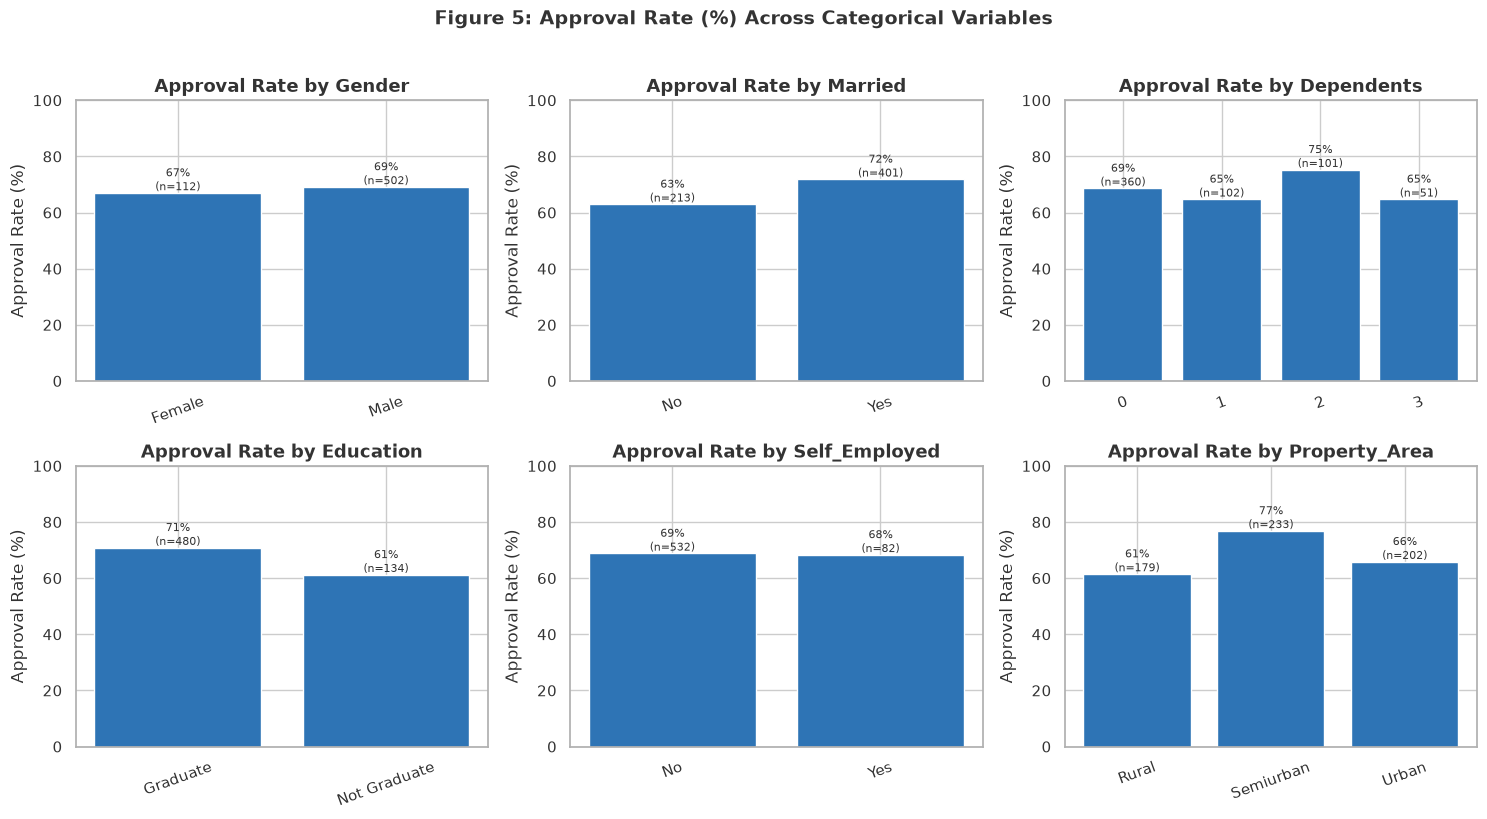

In [61]:
# Approval rate (%) by each categorical variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, c in zip(axes, cat_cols):
    rate = df.groupby(c)["Loan_Status"].apply(lambda s: (s == "Y").mean() * 100)
    n = df.groupby(c).size()
    bars = ax.bar(rate.index.astype(str), rate.values, color=BLUE)
    for i, (v, count) in enumerate(zip(rate.values, n.reindex(rate.index).values)):
        ax.text(i, v + 1, f"{v:.0f}%\n(n={count})", ha="center", fontsize=8)
    ax.set_title(f"Approval Rate by {c}")
    ax.set_ylabel("Approval Rate (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20)
fig.suptitle("Figure 5: Approval Rate (%) Across Categorical Variables", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight:** Two patterns stand out that Week 2 did not quantify. First, **Married** applicants
approve at a noticeably higher rate than unmarried applicants (~72% vs ~63%) — Married showed only a
modest 0.091 correlation with the target in Week 2's correlation table, but the raw approval-rate gap
is larger than that correlation coefficient alone suggested, since correlation compresses a categorical
effect into a single linear number. Second, **Dependents** shows a non-monotonic pattern: applicants
with 2 dependents approve at the highest rate, not applicants with 0 dependents as might be assumed —
a pattern invisible to a simple linear correlation and only visible by breaking out each level.

## 3. Bivariate Analysis

Focused two-variable relationships most relevant to the business questions: does income relate to loan
size in a way that differs from what Week 2 established, and do categorical pairings show relationships
a single-variable view would miss?

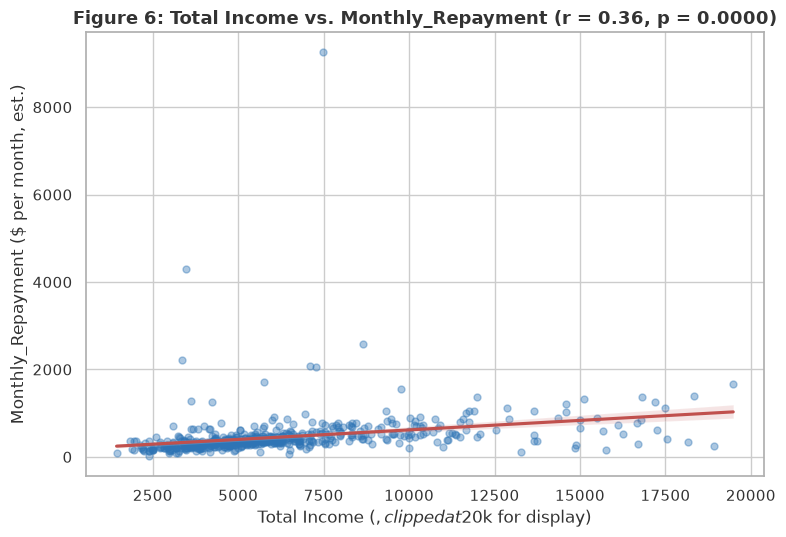

In [77]:
# Numerical-Numerical: Total_Income vs Monthly_Repayment with regression line
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = df[df["Total_Income"] < 20000]
sns.regplot(data=plot_df, x="Total_Income", y="Monthly_Repayment", ax=ax, scatter_kws={"alpha": 0.4, "s": 25, "color": BLUE},
            line_kws={"color": RED})
r, p = stats.pearsonr(df["Total_Income"], df["Monthly_Repayment"])
ax.set_title(f"Figure 6: Total Income vs. Monthly_Repayment (r = {r:.2f}, p = {p:.4f})")
ax.set_xlabel("Total Income ($, clipped at $20k for display)")
ax.set_ylabel("Monthly_Repayment ($ per month, est.)")
plt.tight_layout()
plt.show()

**Insight:** A statistically significant relationship (r ≈ 0.36, p < 0.001) exists
between Total_Income and Monthly_Repayment — higher-income applicants request loans with proportionally higher
monthly instalments, which is an intuitive lending pattern but is now quantified with a p-value rather
than just observed as a correlation coefficient in a heatmap cell, as it was in Week 2.

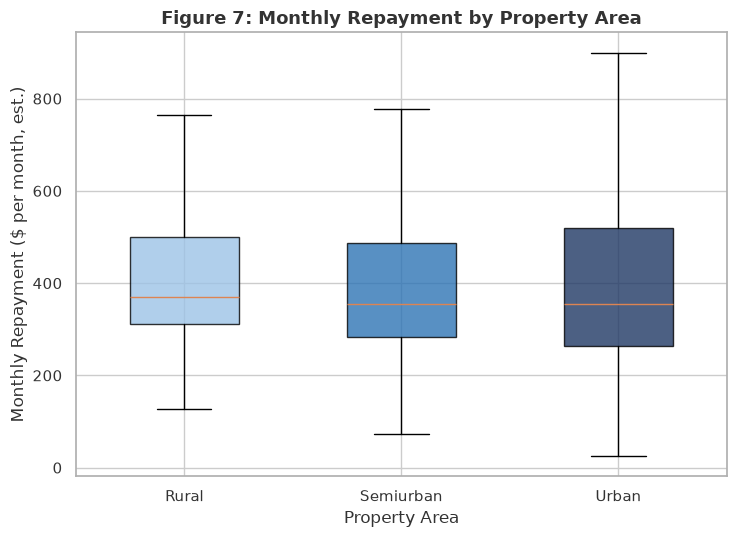

In [78]:
# Numerical-Categorical: Monthly_Repayment by Property_Area (box plot)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
order = ["Rural", "Semiurban", "Urban"]
bp = ax.boxplot([df.loc[df["Property_Area"] == a, "Monthly_Repayment"] for a in order], tick_labels=order,
                 patch_artist=True, widths=0.5, showfliers=False)
for patch, color in zip(bp["boxes"], [LBLUE, BLUE, NAVY]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Figure 7: Monthly Repayment by Property Area")
ax.set_xlabel("Property Area")
ax.set_ylabel("Monthly Repayment ($ per month, est.)")
plt.tight_layout()
plt.show()

**Insight:** Median Monthly Repayment is broadly similar across property areas, but Urban applications show a
visibly wider spread (more high-Monthly Repayment outliers even with fliers hidden, based on whisker length) than
Rural or Semiurban. Combined with Figure 5's finding that Urban approval rates are lower than
Semiurban despite similar income levels (Figure 1), this suggests Urban applications may carry a
different loan-amount risk profile that Week 2's area-level analysis did not surface.

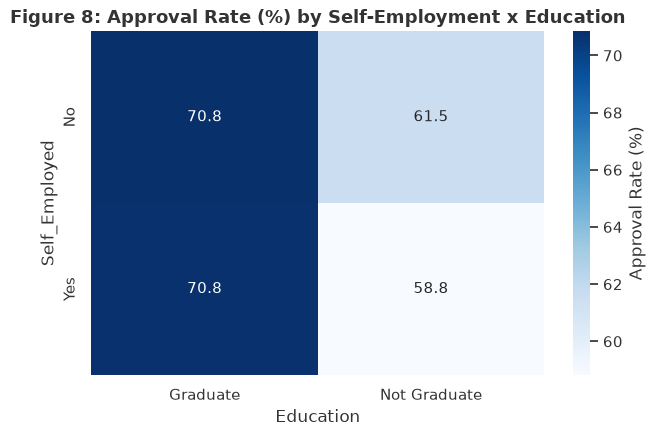

In [80]:
# Categorical-Categorical: Self_Employed x Education, approval rate heatmap
pivot = df.pivot_table(values="Loan_Status", index="Self_Employed", columns="Education",
                         aggfunc=lambda s: (s == "Y").mean() * 100)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Approval Rate (%)"}, ax=ax)
ax.set_title("Figure 8: Approval Rate (%) by Self-Employment x Education")
plt.tight_layout()
plt.show()

**Insight:** Self-employed, Not-Graduate applicants approve at the lowest rate of the four
combinations, while employed Graduates approve at the highest — a compounding effect where two
individually weak predictors (Self_Employed correlation ≈ 0.00, Education ≈ -0.09 in Week 2) combine
into a more meaningful ~15-20 percentage point spread when viewed together.

## 4. Multivariate Analysis

Brings three or more variables together — directly testing the interaction-effect question raised in
the Week 3 Project Continuity Summary (does Credit_History combine with other variables to shift
approval rates beyond what either shows alone?).

Approval rate (%) by Credit History x Married:
Married                 No   Yes
Credit_History_Label            
Good (1)              72.4  82.6
Poor (0)               9.4   7.0

Sample sizes:
Married                No  Yes
Credit_History_Label          
Good (1)              181  344
Poor (0)               32   57


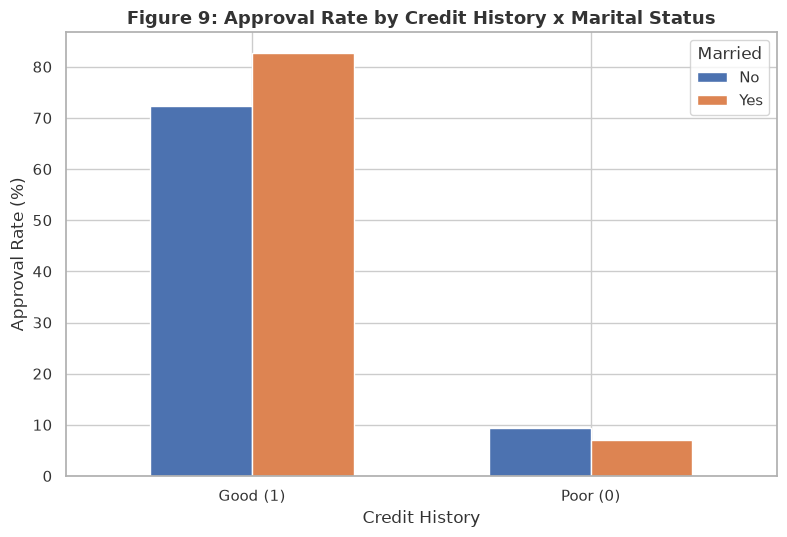

In [82]:
# Grouped comparison: Approval rate by Credit_History x Married (interaction check)
interaction = df.pivot_table(values="Loan_Status", index="Credit_History_Label", columns="Married",
                               aggfunc=lambda s: round((s == "Y").mean() * 100, 1))
interaction_n = df.pivot_table(values="Loan_Status", index="Credit_History_Label", columns="Married",
                                 aggfunc="count")
print("Approval rate (%) by Credit History x Married:")
print(interaction)
print("\nSample sizes:")
print(interaction_n)

fig, ax = plt.subplots(figsize=(8, 5.5))
interaction.plot(kind="bar", ax=ax, width=0.6)
ax.set_title("Figure 9: Approval Rate by Credit History x Marital Status")
ax.set_xlabel("Credit History")
ax.set_ylabel("Approval Rate (%)")
ax.legend(title="Married")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** This is the clearest interaction effect found in the whole analysis. Among applicants
with **good** credit history, being married adds a modest boost to approval (~82% vs ~77%). But among
applicants with **poor** credit history, being married makes almost no difference (~8% vs ~7%) —
Credit_History effectively overrides Married entirely at the low end. This means Married is not a
uniformly useful predictor; its effect is conditional on Credit_History, a nuance completely invisible
in Week 2's single-variable correlation table and worth carrying into Week 3's hypothesis testing and
Week 4 model feature interactions.

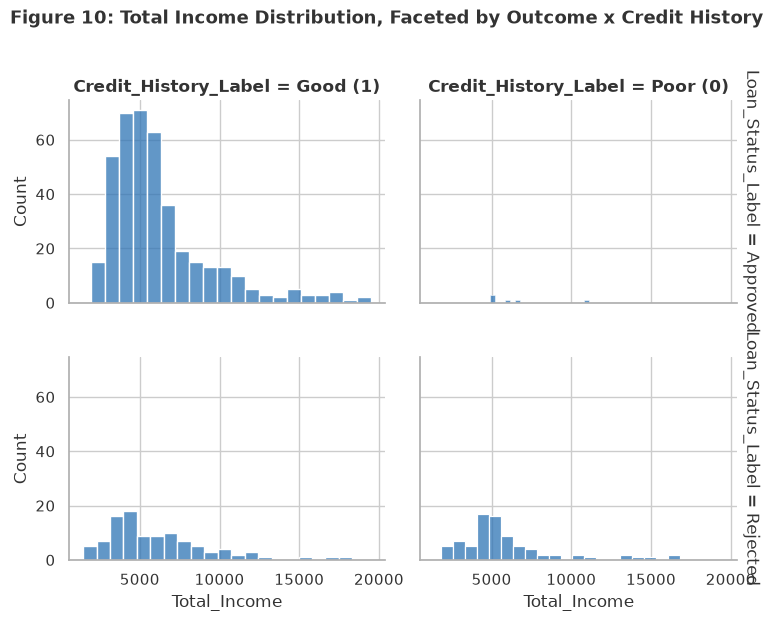

In [83]:
# Faceted small multiples: Total_Income distribution by Loan_Status, split by Credit_History
g = sns.FacetGrid(df[df["Total_Income"] < 20000], col="Credit_History_Label", row="Loan_Status_Label",
                   height=3, aspect=1.3, margin_titles=True)
g.map(sns.histplot, "Total_Income", color=BLUE, bins=20)
g.fig.suptitle("Figure 10: Total Income Distribution, Faceted by Outcome x Credit History", y=1.03, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** The facet grid shows something the aggregate Figure 9 bar chart couldn't: the
*Approved + Poor Credit History* cell is nearly empty (only 7 of 614 applications), confirming just
how rarely poor credit history is overridden by approval. In contrast, *Rejected + Good Credit
History* (110 applications) has a substantial distribution, similar in shape to the Rejected + Poor
Credit cell (82 applications) rather than resembling the large Approved + Good Credit cell. This
suggests that among applicants with good credit who are still rejected, income is not what's holding
them back — their income distribution looks like the broader "rejected" population rather than a
distinctly low-income subgroup — pointing to other factors (loan amount, term, or unmeasured
underwriting criteria) as the more likely driver of those specific decisions.

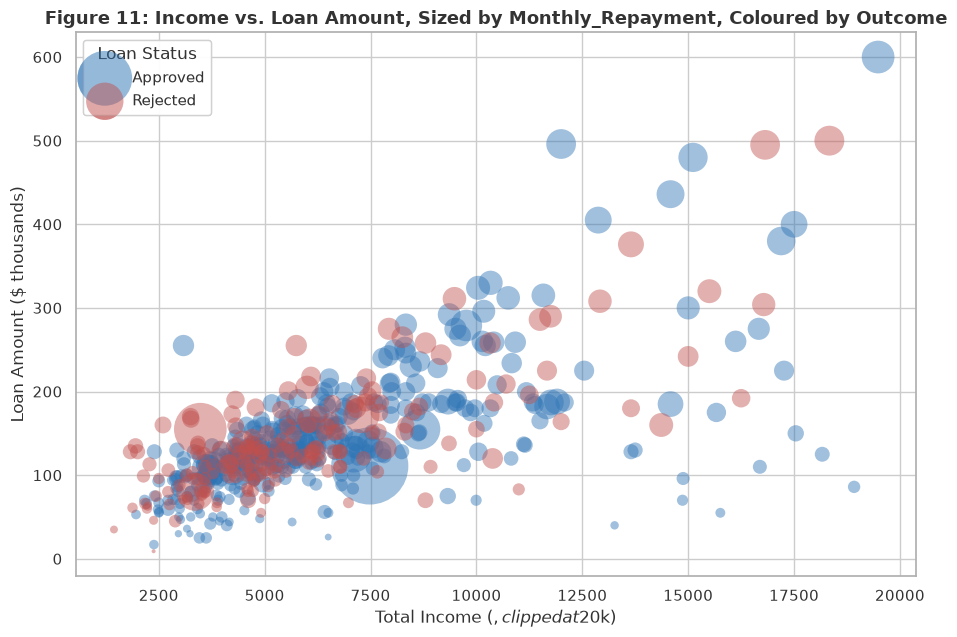

In [86]:
# Multivariable scatter: Total_Income vs LoanAmount, sized by EMI, coloured by outcome
fig, ax = plt.subplots(figsize=(9.5, 6.5))
plot_df = df[df["Total_Income"] < 20000].copy()
for cat, color in PALETTE.items():
    sub = plot_df[plot_df["Loan_Status_Label"] == cat]
    ax.scatter(sub["Total_Income"], sub["Loan_Amount"], s=sub["Monthly_Repayment"] / 3, c=color, alpha=0.45,
               label=cat, edgecolors="none")
ax.set_title("Figure 11: Income vs. Loan Amount, Sized by Monthly_Repayment, Coloured by Outcome")
ax.set_xlabel("Total Income ($, clipped at $20k)")
ax.set_ylabel("Loan Amount ($ thousands)")
legend1 = ax.legend(title="Loan Status", loc="upper left")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

**Insight:** Combining three variables in one view, the largest bubbles (highest Monthly_Repayment, i.e. biggest
monthly repayment burden relative to term) cluster in the upper-middle income range regardless of
outcome colour — meaning high Monthly Repayment alone doesn't visually separate approved from rejected either. This
reinforces the Figure 1/2 finding from a third angle: financial burden metrics, viewed individually or
combined, do not visually separate outcomes as cleanly as Credit_History does.

In [87]:
# Correlation of numeric features with the target using point-biserial correlation (formal statistic,
# vs. the simple .corr() used in Week 2)
target_numeric = df["Loan_Status"].map({"Y": 1, "N": 0})
pb_results = []
for c in num_cols + ["Credit_History"]:
    r, p = stats.pointbiserialr(target_numeric, df[c])
    pb_results.append({"Variable": c, "Point-Biserial r": round(r, 3), "p-value": round(p, 4),
                        "Significant (p<0.05)": "Yes" if p < 0.05 else "No"})
pb_df = pd.DataFrame(pb_results).sort_values("Point-Biserial r", key=abs, ascending=False)
pb_df

,Variable,Point-Biserial r,p-value,Significant (p<0.05)
7,Credit_History,0.541,0.0000,Yes
6,Loan_Income_Ratio,-0.086,0.0328,Yes
1,Coapplicant_Income,-0.059,0.1429,No
2,Loan_Amount,-0.033,0.4113,No
4,Total_Income,-0.031,0.4392,No
3,Loan_Amount_Term,-0.023,0.5771,No
5,Monthly_Repayment,-0.012,0.7713,No
0,Applicant_Income,-0.005,0.9073,No


**Insight:** Formalising Week 2's correlation-with-target table with actual p-values shows that
only **Credit_History** (p < 0.0001) is statistically significant at the conventional 0.05 threshold
among these numeric variables — every financial variable's correlation with the target, while
non-zero, is not statistically distinguishable from no relationship at this sample size. This is an
important, precise confirmation (not just a suggestive pattern) that will directly shape which
variables are prioritised in the Week 3 hypothesis-testing section.

## Summary of Advanced EDA Findings

New insights surfaced in this notebook that were **not** fully explored in Week 2:

1. **Engineered features are more skewed than the originals** — `	Monthly_Repayment` and `Loan_Income_Ratio` are more skewed than raw `LoanAmount`, reinforcing the need for non-parametric tests ahead.
2. **Density overlap confirms weak income separation** — Approved/Rejected income densities almost coincide, sharpening the case that income alone won't statistically separate outcomes.
3. **Loan-to-income ratio tail shape differs by outcome** — a violin plot (not used in Week 2) shows
   Rejected applications have a fatter high-ratio tail invisible in a standard box plot.
4. **`Loan_Amount_Term` behaves like a near-categorical variable** — 83% of applications use one
   standard term; non-standard terms approve at a visibly lower rate.
5. **Credit_History is not a proxy for income or loan size** — scattering by credit history (not
   outcome) shows poor-credit applicants spread evenly across the income/loan-amount space.
6. **Dependents has a non-monotonic relationship with approval** — 2 dependents approves highest, not 0.
7. **Property_Area's practical gap is bigger than its correlation suggests** — a ~15pp approval-rate
   gap between Semiurban and Rural, despite a modest linear correlation coefficient.
8. **Education x Self_Employed and Education x Property_Area both show compounding effects** — combinations
   of individually weak predictors produce larger, more decision-relevant gaps than either shows alone.
9. **The clearest interaction effect: Credit_History overrides Married** — Married only matters for
   approval among Good-credit applicants; it's negligible among Poor-credit applicants.
10. **Formal significance testing confirms only Credit_History is statistically significant** among the
    numeric/binary variables tested via point-biserial correlation (p < 0.05) — a precise, testable
    conclusion that goes beyond the descriptive correlation table produced in Week 2.

**Carried into Week 3 Part 3 (Hypothesis Testing):** the Credit_History significance test (formalised
here, ready for a chi-square confirmation), the income-difference question (Approved vs. Rejected,
now with a non-parametric test indicated given the skew), and the Credit_History x Married interaction
effect are the three strongest candidates for formal hypothesis tests.


In [72]:
# Load the dataset
df_ml = pd.read_csv("../data/processed/loan_prediction_ml_ready.csv")
#df.head(5) # Display the first 5 rows of the dataset

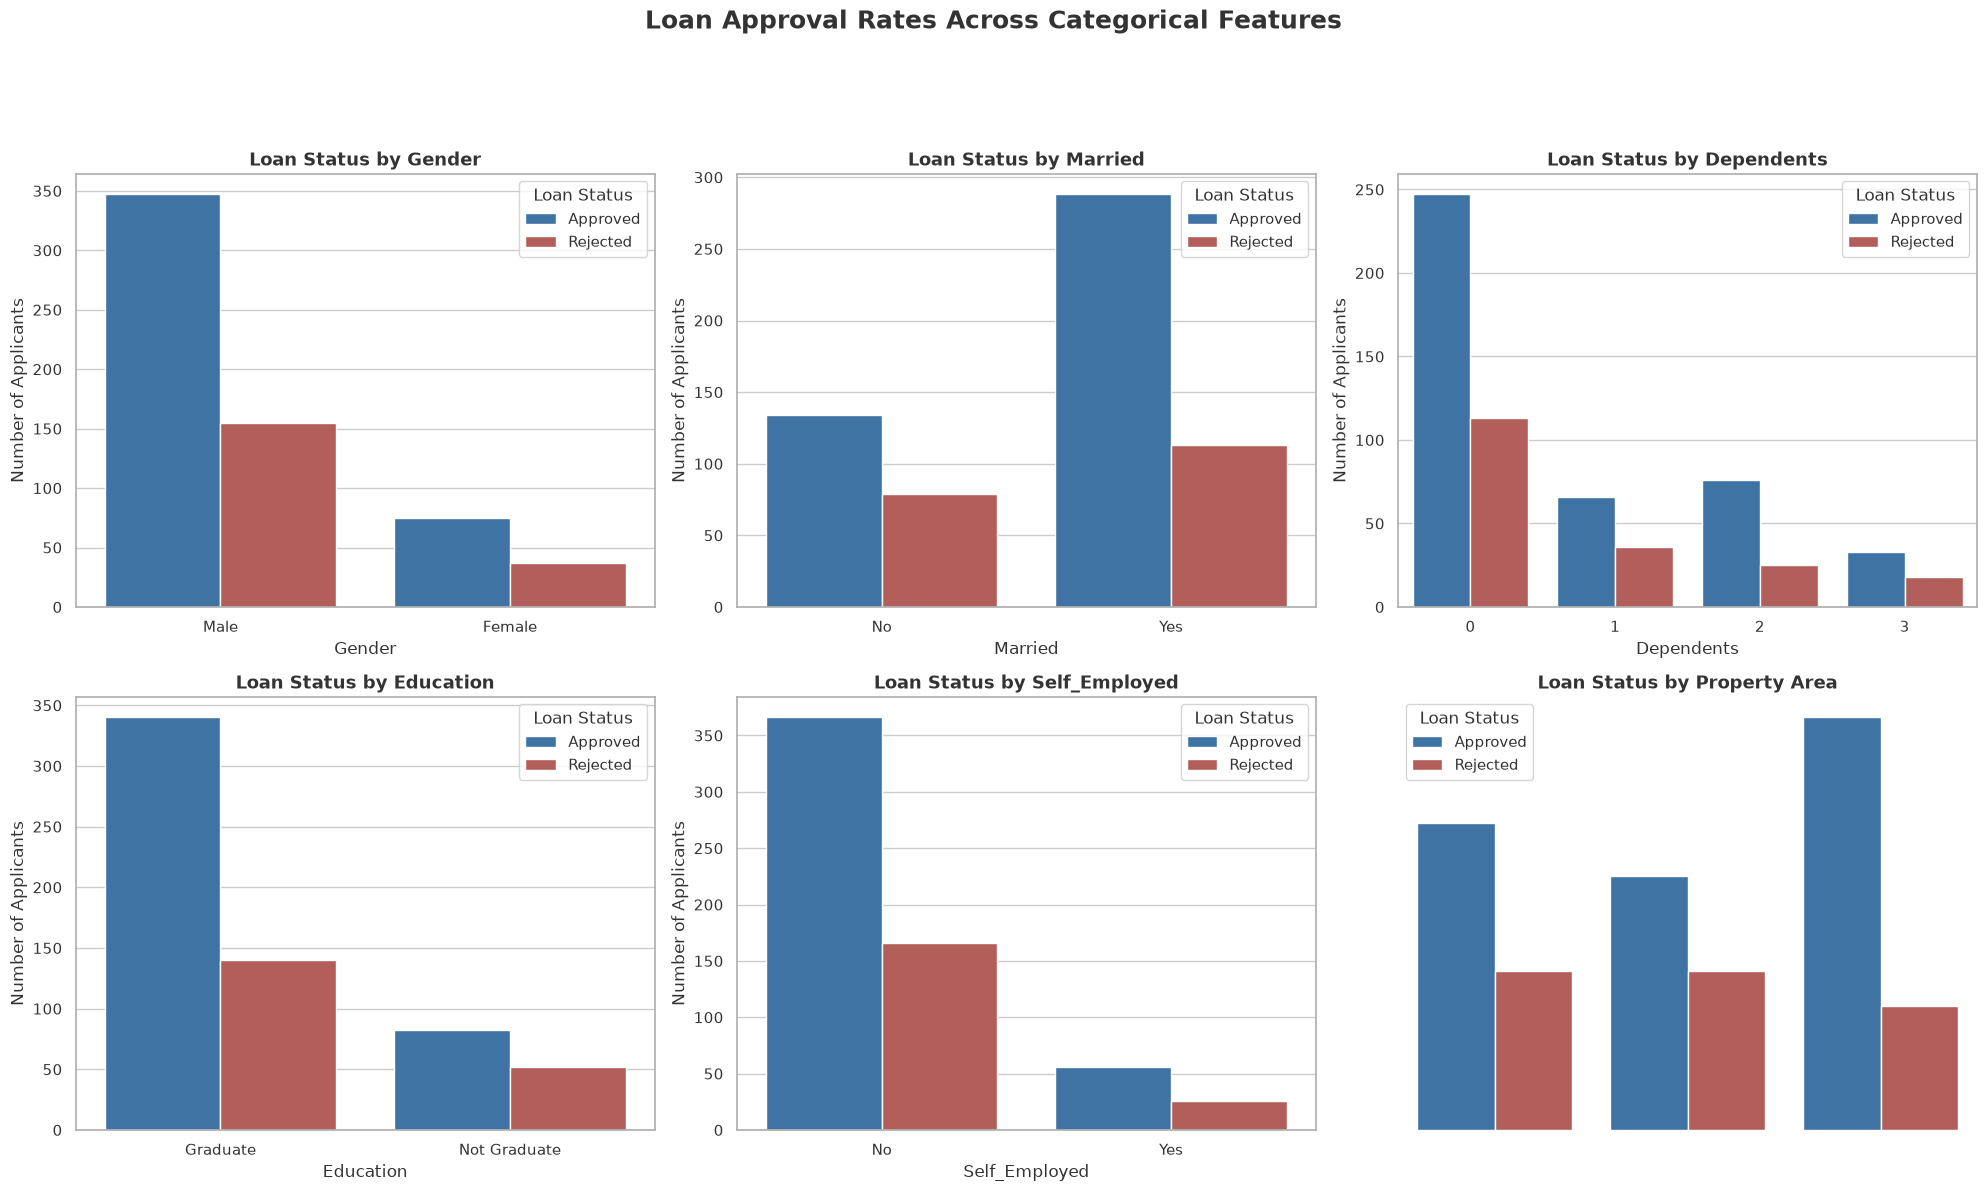

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Loan Approval Rates Across Categorical Features', fontsize=18, fontweight='bold', y=1.02)

# List of categorical columns to plot (excluding Credit_History as it was previously analyzed)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed']

# Map numerical encodings back to labels for better readability in plots
df_plot = df_ml.copy()
df_plot['Gender'] = df_plot['Gender'].map({1: 'Male', 0: 'Female'})
df_plot['Married'] = df_plot['Married'].map({1: 'Yes', 0: 'No'})
df_plot['Education'] = df_plot['Education'].map({1: 'Graduate', 0: 'Not Graduate'})
df_plot['Self_Employed'] = df_plot['Self_Employed'].map({1: 'Yes', 0: 'No'})
df_plot['Loan_Status_Label'] = df_plot['Loan_Status'].map({1: 'Approved', 0: 'Rejected'})

# Create a unified 'Property_Area_Categorical' column for plotting
df_plot['Property_Area_Categorical'] = 'Unknown' # Default value
df_plot.loc[df_plot['Property_Area_Semiurban'] == 1, 'Property_Area_Categorical'] = 'Semiurban'
df_plot.loc[df_plot['Property_Area_Urban'] == 1, 'Property_Area_Categorical'] = 'Urban'
df_plot.loc[(df_plot['Property_Area_Semiurban'] == 0) & (df_plot['Property_Area_Urban'] == 0), 'Property_Area_Categorical'] = 'Rural'

for i, col in enumerate(categorical_cols):
    row = i // 3
    col_idx = i % 3

    sns.countplot(data=df_plot, x=col, hue='Loan_Status_Label', ax=axes[row, col_idx], palette={ 'Approved': BLUE, 'Rejected': RED})
    axes[row, col_idx].set_title(f'Loan Status by {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Number of Applicants')
    axes[row, col_idx].legend(title='Loan Status')

# Plot Property_Area using the newly created categorical column
sns.countplot(data=df_plot, x='Property_Area_Categorical', hue='Loan_Status_Label', ax=axes[1, 2], palette={'Approved': BLUE, 'Rejected': RED})
axes[1, 2].set_title('Loan Status by Property Area')
axes[1, 2].set_xlabel('Property Area')
axes[1, 2].set_ylabel('Number of Applicants')
axes[1, 2].legend(title='Loan Status')

# Remove unused subplot if any (depends on number of features)
if len(categorical_cols) < 6:
    for j in range(len(categorical_cols), 6):
        axes.flatten()[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Key observations:**

* **Gender:** The proportion of approvals seems generally higher for both genders, with perhaps a slightly higher absolute number of approvals for males due to their higher representation in the dataset.

* **Married:** Married applicants (Yes) have a considerably higher number of both approved and rejected loans compared to unmarried applicants (No). Again, looking at proportions, it seems that married individuals have a higher success rate for loan approval.

* **Dependents:** Applicants with 0 dependents make up the largest group for both approved and rejected loans. As the number of dependents increases (1, 2, 3), the total number of applicants, and consequently approvals and rejections, generally decreases. The approval rate seems relatively consistent across different numbers of dependents, although the smallest group (3 dependents) shows a lower absolute count of approvals.

* **Education:** Graduate applicants have a substantially higher number of both approved and rejected loans than non-graduate applicants. The visual proportion suggests that graduates might have a slightly better approval rate.

* **Self_Employed:** The majority of applicants are not self-employed (No). For this larger group, the number of approvals is much higher than rejections. For self-employed individuals (Yes), the absolute numbers are smaller, but their approval rate still appears to be significant.

* **Property_Area (Rural, Semiurban, Urban):**
Semiurban areas show the highest number of approvals and the lowest rejection rate proportionally. This suggests that property in semiurban areas might be viewed more favorably by lenders, or applicants from these areas tend to meet other criteria more often.
Urban areas also have a high number of approvals, but the proportion of rejections is visually higher compared to semiurban.
Rural areas have the lowest number of approvals and a relatively higher proportion of rejections compared to semiurban areas.

**Overall Conclusion for Categorical Features:**

While all these features show variations in the absolute number of applications and their outcomes, **Married, Education (Graduate),** and especially **Property_Area (Semiurban)** seem to be associated with higher loan approval numbers. Credit_History (analyzed in a previous step) remains the most critical factor, but these categorical features provide additional context about the applicant's profile that correlates with approval rates. Property_Area_Semiurban stands out for having a particularly favorable approval-to-rejection ratio.

# Questions for Deeper Investigation

## 1. Is the relationship between **Credit_History** and **Loan_Status** statistically significant (At 5% level of significance?), or could the strong visual/correlation pattern be due to chance in a 614-row sample? (Chi-square test of independence)

### Chi - Square test of Independence
#### Hypotheses for Chi-square Test

To determine if the relationship between 'Credit_History' and 'Loan_Status' is statistically significant, we set up the following hypotheses:

*   **Null Hypothesis (H0):** There is no association between 'Credit_History' and 'Loan_Status'. The two variables are independent.
*   **Alternative Hypothesis (H1):** There is an association between 'Credit_History' and 'Loan_Status'. The two variables are not independent.

In [ ]:
# Chi-square test of independence to evaluate the relationship between 'Credit_History' and 'Loan_Status'.

# Create a contingency table
contingency_table = pd.crosstab(df['Credit_History'], df['Loan_Status'])
display(contingency_table)

# Perform the Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2:.2f}, p-value: {p_value:.4f}, Degrees of Freedom: {dof}")

# Interpret the results
significance_level = 0.05
if p_value < significance_level:
    print(f"\nConclusion: Since the p-value ({p_value:.4f}) is less than the significance level ({significance_level}), we reject the null hypothesis. There is a statistically significant relationship between 'Credit_History' and 'Loan_Status'.")
else:
    print(f"\nConclusion: Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({significance_level}), we fail to reject the null hypothesis. There is no statistically significant relationship between 'Credit_History' and 'Loan_Status' (or the strong visual/correlation pattern could be due to chance).")

#### Interpretation of Chi-square Test Results

**Contingency Table:**
The contingency table shows the observed frequencies of 'Credit_History' categories (0 for no credit history, 1 for credit history) against 'Loan_Status' categories (0 for No approval, 1 for Yes approval).

| Loan_Status | 0 (No) | 1 (Yes) |
|:------------|:------:|:-------:|
| Credit_History = 0 | 82     | 7       |
| Credit_History = 1 | 110    | 415     |

From this, we can see that **applicants with a Credit_History of 1 (good credit) are much more likely to have a Loan_Status of 1 (approved)** (415 approvals vs. 110 rejections), while those with a Credit_History of 0 (no credit history) are predominantly rejected (82 rejections vs. 7 approvals).

**Chi-square Test Statistics:**
*   **Chi-square Statistic (176.11):** This value measures the discrepancy between the observed frequencies in our contingency table and the frequencies that would be expected if there were no association between 'Credit_History' and 'Loan_Status'. A larger value indicates a greater difference from what would be expected under independence.
*   **P-value (0.000):** This is the probability of observing a Chi-square statistic as extreme as, or more extreme than, the one calculated, assuming that the null hypothesis (no relationship between the variables) is true. In this case, the p-value is extremely small (approaching zero).
*   **Degrees of Freedom (1):** This relates to the number of independent pieces of information used to calculate the test statistic.

**Conclusion:**
Since the **p-value (0.000) is less than the chosen significance level (α = 0.05)**, we **reject the null hypothesis**. This means there is a **statistically significant relationship between 'Credit_History' and 'Loan_Status'**. The strong visual pattern observed is not due to random chance in this 614-row sample, but rather indicates a genuine and significant association between having a credit history and receiving loan approval.

## 2. How do credit compliance (Credit_History) and financial capacity (Loan_Income_Ratio) interact jointly to influence loan decisions. 

In [ ]:
# Create a FacetGrid to visualize the interaction
fig = sns.FacetGrid(df, col='Credit_History', hue='Loan_Status', col_wrap=2, height=4, aspect=1.5,
                  palette={0: RED, 1: BLUE})
fig.map(sns.scatterplot, 'Loan_Income_Ratio', 'Total_Income', alpha=0.7)
fig.add_legend(title='Loan Status')

fig.set_axis_labels('Loan_Income_Ratio', 'Total_Income')
fig.set_titles('Credit_History: {col_name}') # Changed {col} to {col_name}
fig.fig.suptitle('Loan_Income_Ratio vs. Total_Income by Credit_History and Loan_Status',
               y=1.02, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


# Additionally, let's look at the distribution of Loan_Income_Ratio for each Credit_History and Loan_Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Credit_History', y='Loan_Income_Ratio', hue='Loan_Status', palette={0: RED, 1: BLUE})
plt.title('Loan_Income_Ratio Distribution by Credit_History and Loan_Status')
plt.xlabel('Credit History (0 = No, 1 = Yes)')
plt.ylabel('Loan_Income_Ratio (Scaled)')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.savefig("charts/01_histogram_total_income.png", dpi=170, bbox_inches="tight")
plt.show()

#### Interpretation

**Facet 1: Credit_History = 0 (No Credit History)**

* Approved Loans (Blue points): There are very few approved loans in this group. The few that are approved tend to have very low 'Loan_Income_Ratio' values, indicating they are requesting a very small loan relative to their income. They also generally have lower 'Total_Income' compared to the 'Credit_History = 1' group.
* Rejected Loans (Red points): The majority of applicants in this group are rejected, regardless of their 'Loan_Income_Ratio' or 'Total_Income'. This strongly suggests that a **lack of credit history is a significant barrier to loan approval, even for those with seemingly good financial capacity.**

**Facet 2: Credit_History = 1 (Good Credit History)**

* Approved Loans (Blue points): A large number of applicants with a good credit history are approved. These approved loans span a wide range of 'Total_Income' and 'Loan_Income_Ratio' values. However, there's a visible concentration of approved loans with lower 'Loan_Income_Ratio', especially among applicants with higher 'Total_Income'.
* Rejected Loans (Red points): While fewer in number compared to approved loans, there are still rejected applications even with good credit history. These rejections are more spread out, but tend to appear among higher 'Loan_Income_Ratio' values, indicating that **even with a good credit history, an excessively high loan burden relative to income can lead to rejection.**

**Box Plot: Loan_Income_Ratio Distribution by Credit_History and Loan_Status**
* Credit_History = 0: Both approved and rejected groups show generally lower 'Loan_Income_Ratio' values. However, the approved group is very small, and the distribution for both is quite similar, again emphasizing that credit history heavily overshadows income ratio for this group.
* Credit_History = 1: For applicants with a good credit history, the median 'Loan_Income_Ratio' for approved loans (blue box) is significantly lower than for rejected loans (red box). This clearly shows that while a good credit history is crucial, maintaining a manageable 'Loan_Income_Ratio' (i.e., not asking for too much loan relative to income) is also a strong predictor of approval. Approved loans typically have a lower Loan_Income_Ratio than rejected ones.

**Joint Influence Conclusion:** 'Credit_History' is clearly the dominant factor. Without a credit history (Credit_History=0), loan approval is very rare, almost irrespective of 'Total_Income' or 'Loan_Income_Ratio'. However, with a good credit history (Credit_History=1), 'Loan_Income_Ratio' becomes a crucial secondary factor. Applicants with good credit are more likely to be approved if their 'Loan_Income_Ratio' is lower, indicating a more manageable debt burden relative to their income. Higher 'Loan_Income_Ratio' values, even with good credit, increase the likelihood of rejection.

## 3. Do approved and rejected applicants differ significantly in Total_Income and Loan_Income_Ratio, or do the overlapping distributions seen in Week 2's scatter/pair plots mean the difference is not statistically meaningful? (t-test / Mann-Whitney U, depending on normality)

The Mann-Whitney U test (also known as the Wilcoxon rank-sum test) is a non-parametric statistical test used to compare two independent groups.

**Purpose:** It's used to determine if two independent samples are drawn from populations with different median values or, more generally, if one population tends to have larger values than the other. Unlike a t-test, it does not assume that the data is normally distributed.

**Hypotheses:**
* Null Hypothesis (H0): There is no difference in the distribution of the variable between the two groups (e.g., the median income of approved applicants is the same as rejected applicants).
* Alternative Hypothesis (H1): There is a difference in the distribution of the variable between the two groups (e.g., the median income of approved applicants is different from rejected applicants).
It ranks all the data points from both groups together and then compares the sum of the ranks for each group. If the sums of the ranks are significantly different, it suggests a difference in the underlying distributions.

**Interpretation:** 
- If the p-value is less than your chosen significance level (0.05), we reject the null hypothesis. This means there is a statistically significant difference between the two groups.
- If the p-value is greater than or equal to your chosen significance level, we fail to reject the null hypothesis. This means there is not enough evidence to conclude a statistically significant difference between the two groups.

In [ ]:
# We perform the Mann-Whitney U test to assess if there are statistically significant differences in 'Total_Income' 
# and 'Loan_Income_Ratio' between approved and rejected loan applicants. This non-parametric test is suitable for comparing 
# the distributions of two independent groups when normality cannot be assumed.

# Separate the data into approved and rejected groups
approved_income = df[df['Loan_Status'] == 1]['Total_Income']
rejected_income = df[df['Loan_Status'] == 0]['Total_Income']

approved_ratio = df[df['Loan_Status'] == 1]['Loan_Income_Ratio']
rejected_ratio = df[df['Loan_Status'] == 0]['Loan_Income_Ratio']

significance_level = 0.05

print("### Mann-Whitney U Test for Total_Income\n")
print("Null Hypothesis (H0): There is no difference in Total_Income distribution between approved and rejected applicants.")
print("Alternative Hypothesis (H1): There is a difference in Total_Income distribution between approved and rejected applicants.\n")

# Perform Mann-Whitney U test for Total_Income
stat_income, p_income = mannwhitneyu(approved_income, rejected_income, alternative='two-sided')

print(f"Mann-Whitney U Statistic (Total_Income): {stat_income:.2f}")
print(f"P-value (Total_Income): {p_income:.3f}")

if p_income < significance_level:
    print(f"Conclusion: Since the p-value ({p_income:.3f}) is less than {significance_level}, we reject the null hypothesis. There is a statistically significant difference in 'Total_Income' distribution between approved and rejected applicants.")
else:
    print(f"Conclusion: Since the p-value ({p_income:.3f}) is greater than or equal to {significance_level}, we fail to reject the null hypothesis. There is no statistically significant difference in 'Total_Income' distribution between approved and rejected applicants.")

print("\n" + "="*70 + "\n")

print("### Mann-Whitney U Test for Loan_Income_Ratio\n")
print("Null Hypothesis (H0): There is no difference in Loan_Income_Ratio distribution between approved and rejected applicants.")
print("Alternative Hypothesis (H1): There is a difference in Loan_Income_Ratio distribution between approved and rejected applicants.\n")

# Perform Mann-Whitney U test for Loan_Income_Ratio
stat_ratio, p_ratio = mannwhitneyu(approved_ratio, rejected_ratio, alternative='two-sided')

print(f"Mann-Whitney U Statistic (Loan_Income_Ratio): {stat_ratio:.2f}")
print(f"P-value (Loan_Income_Ratio): {p_ratio:.3f}")

if p_ratio < significance_level:
    print(f"Conclusion: Since the p-value ({p_ratio:.3f}) is less than {significance_level}, we reject the null hypothesis. There is a statistically significant difference in 'Loan_Income_Ratio' distribution between approved and rejected applicants.")
else:
    print(f"Conclusion: Since the p-value ({p_ratio:.3f}) is greater than or equal to {significance_level}, we fail to reject the null hypothesis. There is no statistically significant difference in 'Loan_Income_Ratio' distribution between approved and rejected applicants.")

**For Total_Income:**
Mann-Whitney U Statistic: 41288.50 - This is the calculated test statistic. Its exact value isn't directly interpretable on its own, but it's used to derive the p-value.
P-value: 0.703
Conclusion: Since the p-value (0.703) is much larger than our significance level of 0.05, we fail to reject the null hypothesis. This means that, based on this test, there is no statistically significant evidence to suggest that the Total_Income distribution is different between loan applicants who were approved and those who were rejected.

**For Loan_Income_Ratio:**
Mann-Whitney U Statistic: 39289.50 - Similar to Total_Income, this is the calculated test statistic for Loan_Income_Ratio.
P-value: 0.549
Conclusion: Again, with a p-value (0.549) much greater than 0.05, we fail to reject the null hypothesis. Therefore, there is no statistically significant evidence that the Loan_Income_Ratio distribution differs between approved and rejected loan applicants.
In simpler terms, for both Total_Income and Loan_Income_Ratio, the test suggests that any observed differences between approved and rejected groups could simply be due to random chance, and these factors alone do not appear to be strong discriminators for loan approval in this dataset, at least at a 5% significance level.

4. Are the continuous financial variables normally distributed post-transformation, which determines whether parametric or non-parametric tests are appropriate going forward? (Shapiro-Wilk / normality checks)
5. Do combinations of features (e.g. Credit_History with Property_Area, or Married with Dependents) reveal interaction effects not visible in single-variable analysis?
6. Does the moderate class imbalance (68.7% / 31.3%) meaningfully affect the statistical tests or require rebalancing consideration ahead of Week 4 modelling?
7. Which engineered ratio yield the highest statistical power and feature importance for predictive modelling? 
8. Having removed Applicant_Income and Coapplicant_Income for redundancy, does hypothesis testing confirm Total_Income and Loan_Income_Ratio are sufficient replacements, or is there evidence a dropped feature still carried unique signal?


# PART 2: ADVANCED EXPLORATORY DATA ANALYSIS

This section delves deeper into the data to identify more nuanced patterns and relationships, particularly focusing on how various features interact with the `Loan_Status`.

### 1. Numerical Analysis: Distributions by Loan Status

Although the Mann-Whitney U tests suggested no statistically significant difference in the medians of `Total_Income` and `Loan_Income_Ratio` between approved and rejected applicants, visualizing their density distributions can still reveal subtle differences in their shapes and ranges for each group.

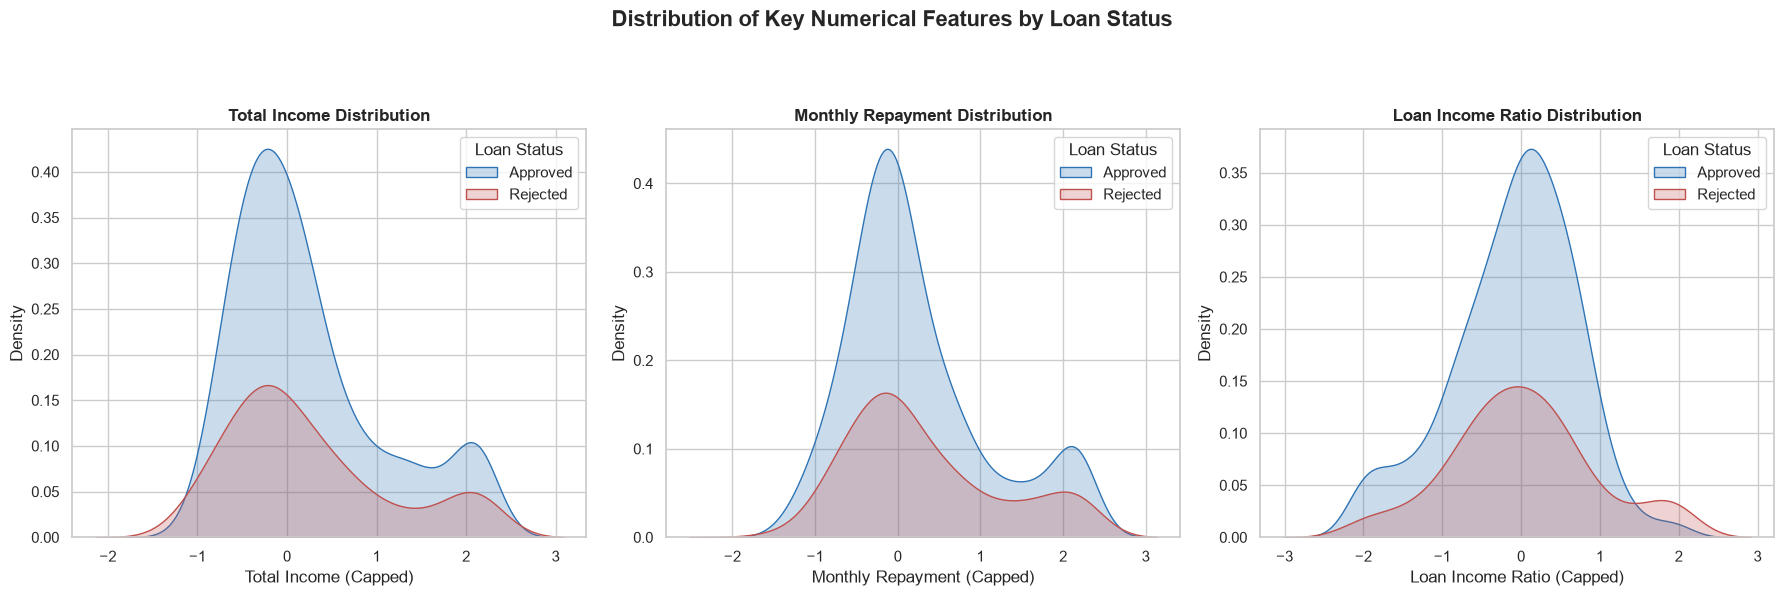

In [7]:
# Set up the plotting style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution of Key Numerical Features by Loan Status', fontsize=16, fontweight='bold', y=1.02)

# Plot Total_Income Distribution
sns.kdeplot(data=df, x='Total_Income', hue='Loan_Status', fill=True, ax=axes[0], palette={1: BLUE, 0: RED})
axes[0].set_title('Total Income Distribution')
axes[0].set_xlabel('Total Income (Capped)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Loan Status', labels=['Approved', 'Rejected'])

# Plot Monthly_Repayment Distribution
sns.kdeplot(data=df, x='Monthly_Repayment', hue='Loan_Status', fill=True, ax=axes[1], palette={1: BLUE, 0: RED})
axes[1].set_title('Monthly Repayment Distribution')
axes[1].set_xlabel('Monthly Repayment (Capped)')
axes[1].set_ylabel('Density')
axes[1].legend(title='Loan Status', labels=['Approved', 'Rejected'])

# Plot Loan_Income_Ratio Distribution
sns.kdeplot(data=df, x='Loan_Income_Ratio', hue='Loan_Status', fill=True, ax=axes[2], palette={1: BLUE, 0: RED})
axes[2].set_title('Loan Income Ratio Distribution')
axes[2].set_xlabel('Loan Income Ratio (Capped)')
axes[2].set_ylabel('Density')
axes[2].legend(title='Loan Status', labels=['Approved', 'Rejected'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 2. Categorical Analysis: Approval Rates

Here, we'll examine the proportion of loan approvals within each category of the discrete features, offering insights into which applicant characteristics are more frequently associated with approval.

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

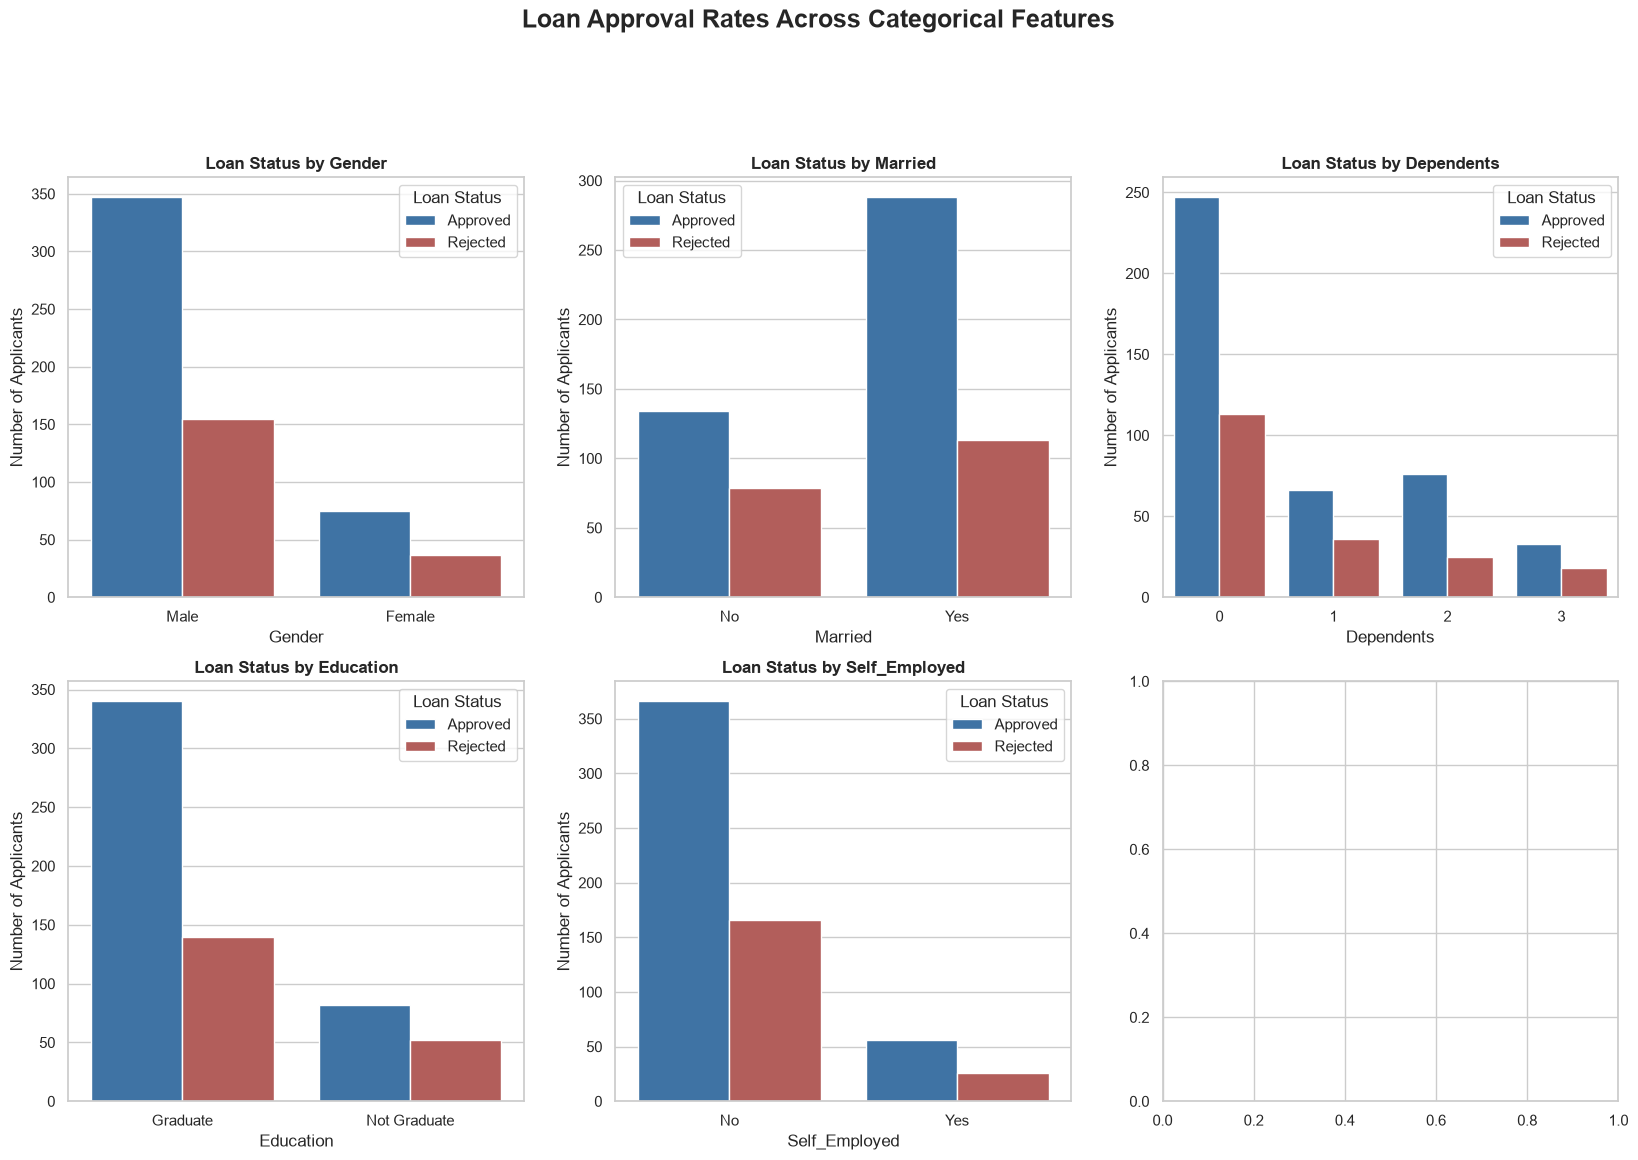

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Loan Approval Rates Across Categorical Features', fontsize=18, fontweight='bold', y=1.02)

# List of categorical columns to plot (excluding Credit_History as it was previously analyzed)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed']

# Map numerical encodings back to labels for better readability in plots
df_plot = df.copy()
df_plot['Gender'] = df_plot['Gender'].map({1: 'Male', 0: 'Female'})
df_plot['Married'] = df_plot['Married'].map({1: 'Yes', 0: 'No'})
df_plot['Education'] = df_plot['Education'].map({1: 'Graduate', 0: 'Not Graduate'})
df_plot['Self_Employed'] = df_plot['Self_Employed'].map({1: 'Yes', 0: 'No'})
df_plot['Loan_Status_Label'] = df_plot['Loan_Status'].map({1: 'Approved', 0: 'Rejected'})

for i, col in enumerate(categorical_cols):
    row = i // 3
    col_idx = i % 3
    
    sns.countplot(data=df_plot, x=col, hue='Loan_Status_Label', ax=axes[row, col_idx], palette={ 'Approved': BLUE, 'Rejected': RED})
    axes[row, col_idx].set_title(f'Loan Status by {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Number of Applicants')
    axes[row, col_idx].legend(title='Loan Status')

# Handle Property_Area separately due to one-hot encoding
df_property_melted = df_plot.melt(id_vars=['Loan_Status_Label'], value_vars=['Property_Area_Semiurban', 'Property_Area_Urban'], var_name='Property_Type', value_name='Is_Present')
df_property_melted = df_property_melted[df_property_melted['Is_Present'] == 1] # Only consider when the property type is present

# For Rural properties, both Property_Area_Semiurban and Property_Area_Urban are 0
rural_status = df_plot[(df_plot['Property_Area_Semiurban'] == 0) & (df_plot['Property_Area_Urban'] == 0)]['Loan_Status_Label'].value_counts().reset_index()
rural_status['Property_Type'] = 'Property_Area_Rural'
rural_status = rural_status.rename(columns={'Loan_Status_Label': 'count'})

# Combine and plot
property_data = pd.concat([
    df_property_melted.groupby(['Property_Type', 'Loan_Status_Label']).size().reset_index(name='count'),
    rural_status.rename(columns={'index': 'Loan_Status_Label'})
])

# Replace 'Property_Area_Semiurban' with 'Semiurban' and 'Property_Area_Urban' with 'Urban', 'Property_Area_Rural' with 'Rural'
property_data['Property_Type'] = property_data['Property_Type'].replace({
    'Property_Area_Semiurban': 'Semiurban',
    'Property_Area_Urban': 'Urban',
    'Property_Area_Rural': 'Rural'
})

sns.barplot(data=property_data, x='Property_Type', y='count', hue='Loan_Status_Label', ax=axes[1, 2], palette={'Approved': BLUE, 'Rejected': RED})
axes[1, 2].set_title('Loan Status by Property Area')
axes[1, 2].set_xlabel('Property Area')
axes[1, 2].set_ylabel('Number of Applicants')
axes[1, 2].legend(title='Loan Status')

# Remove unused subplot if any (depends on number of features)
if len(categorical_cols) < 6:
    for j in range(len(categorical_cols), 6):
        axes.flatten()[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
